# Filtro pasa bajos


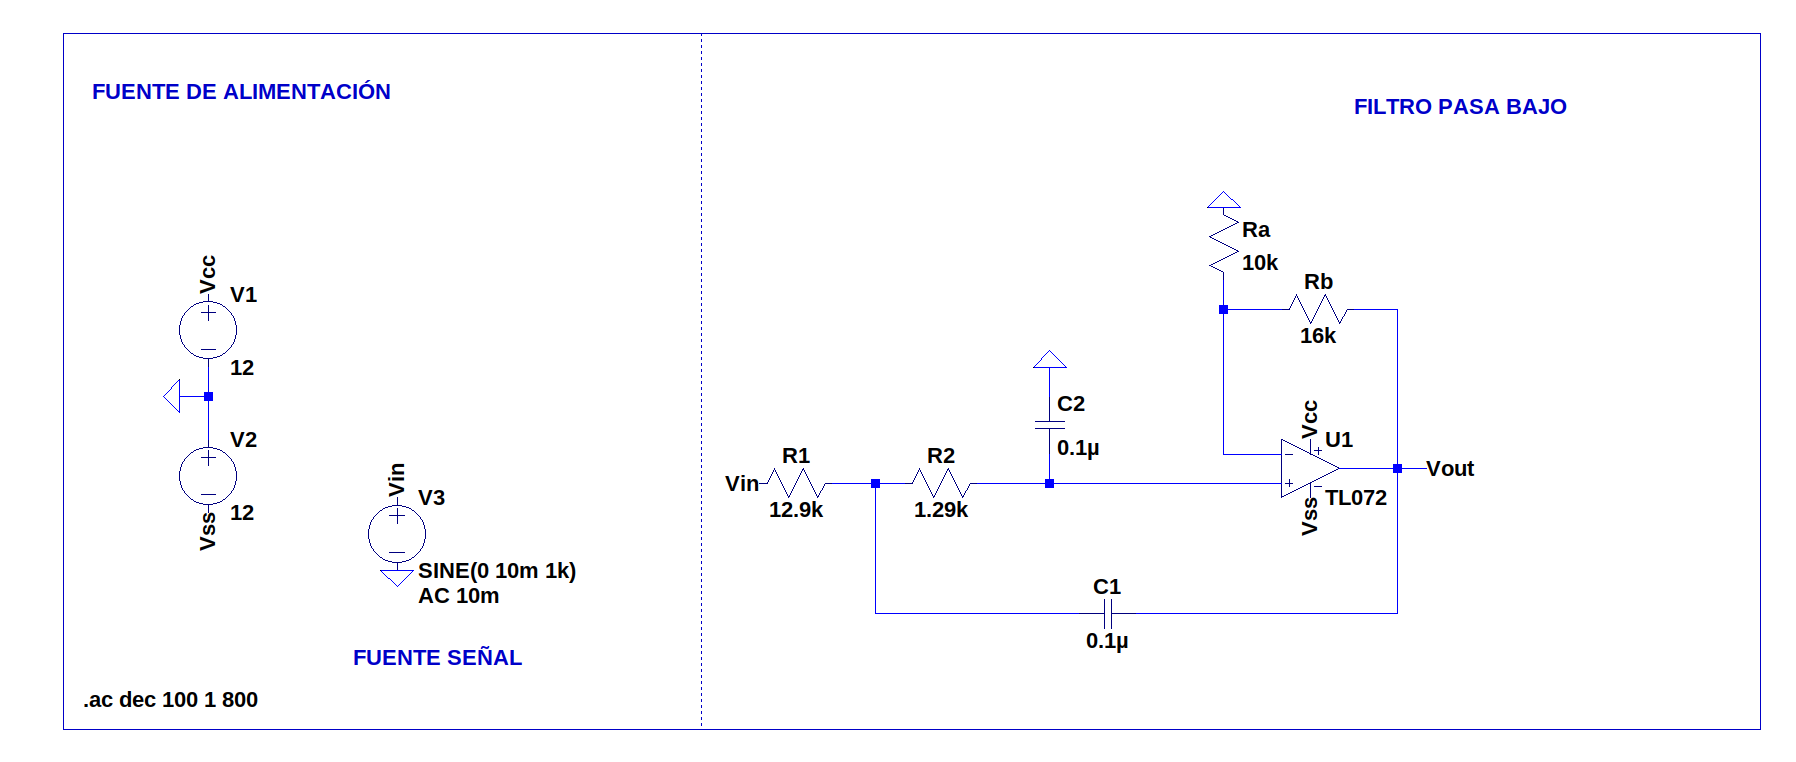

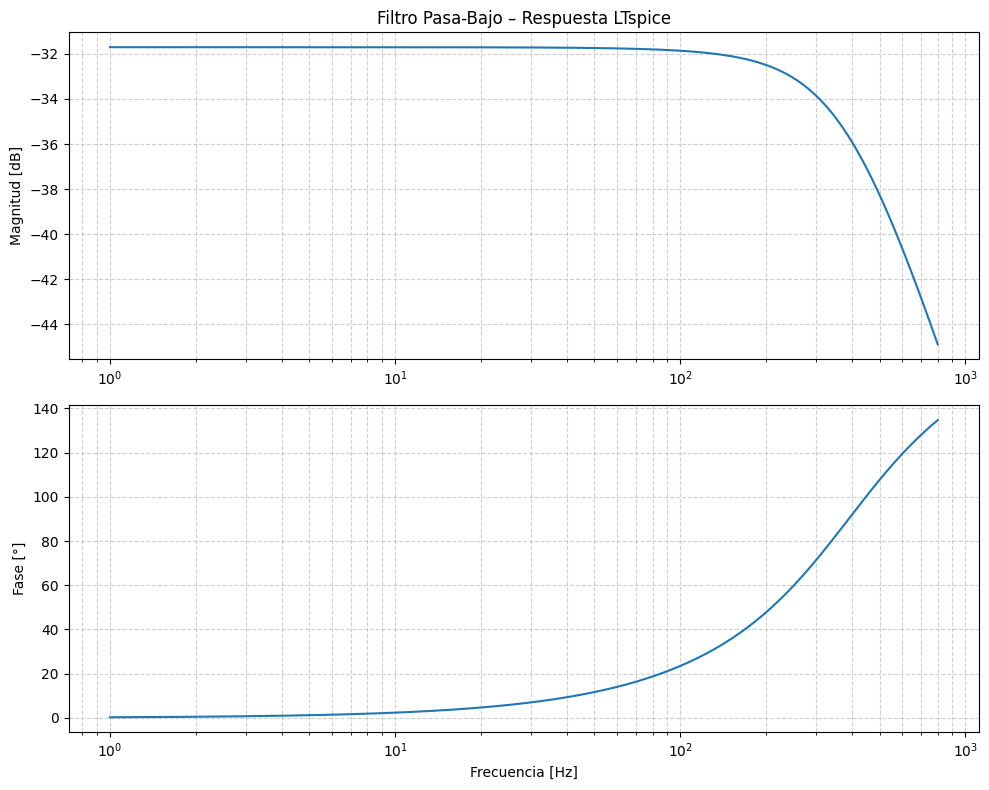

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#  Lectura del archivo exportado desde LTspice
#  Formato:  Freq   Re,Im
# ======================================================

def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado (Freq.   V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            # Frecuencia
            f_val = float(parts[0])

            # Segundo campo: "Re,Im"
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq)
    re_v = np.array(re_v)
    im_v = np.array(im_v)

    # Magnitud y fase
    v_c = re_v + 1j * im_v
    mag_db = 20*np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  Graficar bode pasabajo
# ======================================================

filename = "filtro_pb.txt"   # <-- Cambiar si tu archivo tiene otro nombre

freq, mag_db, phase_deg = load_ltspice_complex(filename)

plt.figure(figsize=(10,8))

# ---------------------------------------
# Magnitud
# ---------------------------------------
plt.subplot(2,1,1)
plt.semilogx(freq, mag_db, label="Pasa-Bajo (LTspice)", color="tab:blue")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Magnitud [dB]")
plt.title("Filtro Pasa-Bajo – Respuesta LTspice")

# ---------------------------------------
# Fase
# ---------------------------------------
plt.subplot(2,1,2)
plt.semilogx(freq, phase_deg, color="tab:blue")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Fase [°]")
plt.xlabel("Frecuencia [Hz]")

plt.tight_layout()
plt.show()



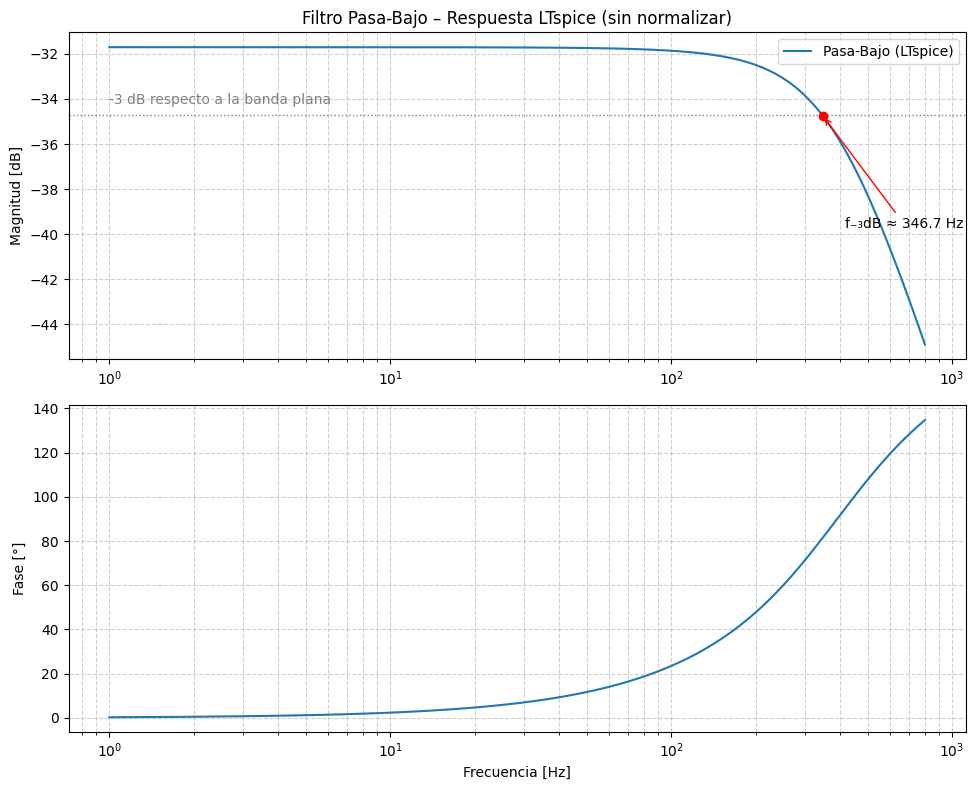

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
#  Lectura del archivo exportado desde LTspice
#  Formato:  Freq   Re,Im
# ======================================================

def load_ltspice_complex(filename):
    freq = []
    re_v = []
    im_v = []

    with open(filename, "r") as f:
        next(f)  # saltear encabezado (Freq.   V(vout))
        for line in f:
            line = line.strip()
            if not line:
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            # Frecuencia
            f_val = float(parts[0])

            # Segundo campo: "Re,Im"
            comp = parts[1]
            re_str, im_str = comp.split(',')
            re_val = float(re_str)
            im_val = float(im_str)

            freq.append(f_val)
            re_v.append(re_val)
            im_v.append(im_val)

    freq = np.array(freq)
    re_v = np.array(re_v)
    im_v = np.array(im_v)

    # Magnitud y fase
    v_c = re_v + 1j * im_v
    mag_db = 20*np.log10(np.abs(v_c))
    phase_deg = np.angle(v_c, deg=True)

    return freq, mag_db, phase_deg


# ======================================================
#  Graficar bode pasabajo con caída -3dB (sin normalizar)
# ======================================================

filename = "filtro_pb.txt"   # <-- Cambiar si tu archivo tiene otro nombre

freq, mag_db, phase_deg = load_ltspice_complex(filename)

# Punto -3 dB respecto al valor plano (máximo)
max_gain = np.max(mag_db)
target = max_gain - 3

# Buscar primer cruce hacia abajo
idx_3db = np.where(mag_db <= target)[0][0]
f_3db = freq[idx_3db]
mag_3db = mag_db[idx_3db]

plt.figure(figsize=(10,8))

# ---------------------------------------
# MAGNITUD
# ---------------------------------------
plt.subplot(2,1,1)
plt.semilogx(freq, mag_db, label="Pasa-Bajo (LTspice)", color="tab:blue")

# Línea horizontal del -3 dB (absoluta)
plt.axhline(target, color='gray', linestyle=':', linewidth=1)
plt.text(freq[0], target + 0.5, "-3 dB respecto a la banda plana", color="gray")

# Punto marcado
plt.semilogx(f_3db, mag_3db, 'ro')
plt.annotate(f"f₋₃dB ≈ {f_3db:.1f} Hz",
             xy=(f_3db, mag_3db),
             xytext=(1.2*f_3db, mag_3db - 5),
             arrowprops=dict(arrowstyle='->', color='red'))

plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Magnitud [dB]")
plt.title("Filtro Pasa-Bajo – Respuesta LTspice (sin normalizar)")
plt.legend()

# ---------------------------------------
# FASE
# ---------------------------------------
plt.subplot(2,1,2)
plt.semilogx(freq, phase_deg, color="tab:blue")
plt.grid(True, which='both', ls='--', alpha=0.6)
plt.ylabel("Fase [°]")
plt.xlabel("Frecuencia [Hz]")

plt.tight_layout()
plt.show()
